In [ ]:
!pip install transformers datasets scikit-learn

import torch
from transformers import BertTokenizer, BertForSequenceClassification
from sklearn.metrics import accuracy_score, classification_report

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
!pip install transformers scikit-learn pandas

import torch
import pandas as pd
from transformers import BertTokenizer, BertForSequenceClassification
from sklearn.metrics import accuracy_score, classification_report

In [ ]:
model_path = "/content/drive/MyDrive/my-folder"

tokenizer = BertTokenizer.from_pretrained("/content/drive/MyDrive/my-folder/tokenizer")
model = BertForSequenceClassification.from_pretrained("/content/drive/MyDrive/my-folder/bert_model")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
model.eval()

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

BertForSequenceClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e-12,

In [ ]:
df = pd.read_csv("/content/drive/MyDrive/my-folder/test.csv")  # must have: text, label

texts = df["text"].tolist()
labels = df["label"].tolist()

In [ ]:
batch_size = 16
predictions = []

for i in range(0, len(texts), batch_size):
    batch_texts = texts[i:i+batch_size]

    encodings = tokenizer(
        batch_texts,
        padding=True,
        truncation=True,
        max_length=128,
        return_tensors="pt"
    )

    encodings = {k: v.to(device) for k, v in encodings.items()}

    with torch.no_grad():
        outputs = model(**encodings)
        logits = outputs.logits
        preds = torch.argmax(logits, dim=1).cpu().numpy()
        predictions.extend(preds)

In [ ]:
accuracy = accuracy_score(labels, predictions)
print("✅ Accuracy:", accuracy)

print("\n📊 Classification Report:")
print(classification_report(labels, predictions))

✅ Accuracy: 0.8600314712824547

📊 Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.85      0.86      6266
           1       0.86      0.86      0.86      6444

    accuracy                           0.86     12710
   macro avg       0.86      0.86      0.86     12710
weighted avg       0.86      0.86      0.86     12710



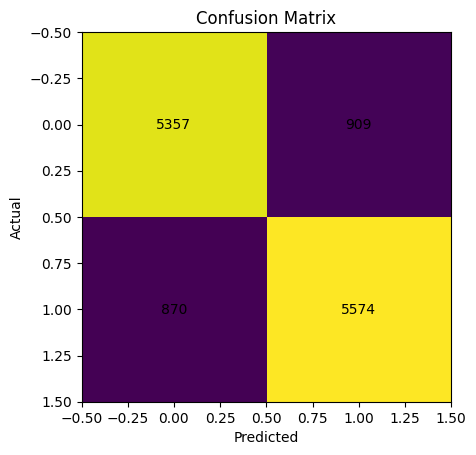

In [ ]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

cm = confusion_matrix(labels, predictions)

plt.figure()
plt.imshow(cm)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

for i in range(len(cm)):
    for j in range(len(cm[0])):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.show()

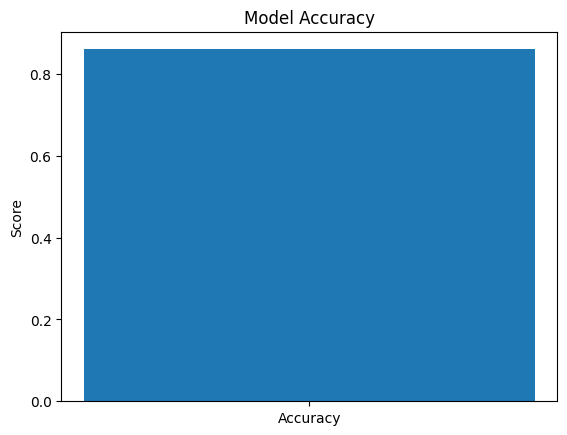

In [ ]:
accuracy = accuracy_score(labels, predictions)

plt.figure()
plt.bar(["Accuracy"], [accuracy])
plt.title("Model Accuracy")
plt.ylabel("Score")
plt.show()

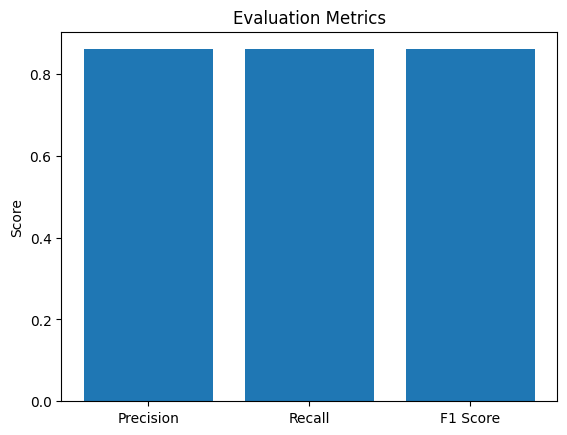

In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score

precision = precision_score(labels, predictions, average='weighted')
recall = recall_score(labels, predictions, average='weighted')
f1 = f1_score(labels, predictions, average='weighted')

metrics = ["Precision", "Recall", "F1 Score"]
values = [precision, recall, f1]

plt.figure()
plt.bar(metrics, values)
plt.title("Evaluation Metrics")
plt.ylabel("Score")
plt.show()